# Feature importance assessment and validation

This notebook assesses and validates the variables considered most important for downstream $N_2O$ modelling using the preprocessed and aligned, 10-minute resolution dataset. These variables were not originally selected through a formal feature selection procedure. Instead, they were identified earlier in the project as the most operationally and biologically relevant variables, based on literature review, process understanding, and exploratory data analysis. They also informed earlier preprocessing decisions, particularly when determining which periods of the dataset should be excluded due to long contiguous gaps in key signals.

For this reason, the purpose of this notebook is not to perform feature selection from scratch on the raw dataset. Rather, it is to evaluate whether the decisions to treat certain variables as most important are well supported by the processed data and remain justified as the core inputs for subsequent modelling. The analysis therefore provides validation of those earlier decisions, while also assessing whether any additional variables should be retained, deprioritised, or interpreted with caution.

This notebook draws on findings from both the global and localised exploratory data analysis completed prior. In particular, it examines whether variables identified as important in the literature and EDA continue to show meaningful relationships with $N_2O$ in the aligned dataset, and whether those relationships appear consistent enough to support their inclusion in forecasting and classification.

The analysis will consider feature importance from several complementary perspectives. This includes reviewing pairwise relationships with N2O, examining correlations between predictors, checking for redundancy and multicollinearity, and comparing simple statistical and model-based measures of relevance. Where appropriate, these findings will be interpreted in the context of the biological processes governing $N_2O$ production. The notebook also explores whether the selected variables retain useful explanatory and predictive signal for the continuous $N_2O$ response, using simple baseline regression models and feature ablation checks as a preliminary validation step before more advanced modelling.

Overall, this notebook is intended to provide a transparent and defensible justification for the variables carried forward into the modelling stage. The notebook therefore evaluates whether the variables that informed earlier preprocessing decisions remain well justified as core inputs for subsequent modelling.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as sns

# Load the dataset
df = pd.read_csv('C:\\Users\\tomor\\Documents\\MSc Lecture Notes\\Data Science Project\\EDS_Design_Project\\data\\EDA\\df_10T.csv')


print("\nSummary statistics:")
display(df.describe())

display(df.head()) 


Summary statistics:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
count,104189.000000,100620.000000,102459.000000,104188.000000,104190.000000,103782.000000,92561.000000,94565.000000,104190.000000,101370.000000,...,104162.0,94565.000000,104190.000000,101370.000000,92561.0,92561.0,92561.0,104138.000000,90758.000000,92561.0
mean,17132.238633,44.470745,0.128340,2.311437,3.116311,0.653175,0.655985,2187.268389,2.552777,15.660482,...,0.0,0.007423,0.136078,0.099724,0.0,0.0,0.0,0.036951,0.016913,0.0
std,6901.956401,40.266240,0.225140,2.200410,2.771673,0.569061,0.540993,2020.493134,0.852093,3.381279,...,0.0,0.085840,0.342873,0.299633,0.0,0.0,0.0,0.188642,0.128947,0.0
min,0.000000,0.000000,0.000000,0.004305,0.338735,0.004268,0.000000,0.000000,0.000000,8.437862,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
25%,12190.833301,0.000000,0.014931,0.965082,1.526463,0.196036,0.000000,0.000000,2.133389,12.618092,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
50%,16668.433398,43.500000,0.037731,1.869051,2.511774,0.437970,1.000000,2190.054934,2.548741,15.635127,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
75%,21168.386328,85.740001,0.136227,3.022755,4.062157,1.042372,1.040527,3938.204852,2.957333,18.901096,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
max,43046.753906,99.099998,2.093171,20.009645,52.849318,10.886502,2.500000,10164.025195,8.780283,27.126736,...,0.0,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,0.0


,time,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
0,2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
1,2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2,2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
3,2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0


## Define key variables and assess pairwise relationships

After initial dataset inspection and preprocessing summaries, the next stage of this notebook focuses on the variables previously treated as most important in preprocessing and exploratory analysis. The aim is to examine whether these variables continue to show meaningful relationships with $N_2O$ in the processed dataset, while also checking for redundancy and overlap between predictors. This provides an initial basis for validating the variables taken forward into modelling.

In [3]:
# Define target and key variables for validation

target = "t1_n2o"

key_vars = [
    "t1_nh4",
    "t1_no3",
    "t1_do",
    "t1_airflow",
    "t1_temp",
    "total_airflow",
    "t1_do_sp",
    "t1_ss",
    "t1_po4",
    "inflow",
    "t1_valve_pct"
]

# Keep only columns that actually exist
key_vars = [col for col in key_vars if col in df.columns]

print("Target:", target)
print("Variables being assessed:")
print(key_vars)

# Create a working dataframe for the feature assessment stage
feature_df = df[[target] + key_vars].copy()

print("\nShape of feature assessment dataframe:", feature_df.shape)
print("\nMissingness within selected variables (%):")
display((feature_df.isna().mean() * 100).sort_values(ascending=False).to_frame(name="missing_%"))

Target: t1_n2o
Variables being assessed:
['t1_nh4', 't1_no3', 't1_do', 't1_airflow', 't1_temp', 'total_airflow', 't1_do_sp', 't1_ss', 't1_po4', 'inflow', 't1_valve_pct']

Shape of feature assessment dataframe: (105264, 12)

Missingness within selected variables (%):


,missing_%
inflow,13.633341
t1_do_sp,12.067753
t1_airflow,10.163969
t1_valve_pct,4.411765
t1_temp,3.699270
t1_n2o,2.664729
t1_do,1.407889
t1_po4,1.069691
t1_nh4,1.022192
total_airflow,1.021242


In [4]:
# Spearman correlations with N2O
spearman_corr = (
    df[[target] + key_vars]
    .corr(method="spearman")[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Spearman correlations with t1_n2o:")
display(spearman_corr.to_frame(name="spearman_corr"))

Spearman correlations with t1_n2o:


,spearman_corr
t1_ss,-0.303256
t1_po4,-0.299144
t1_temp,0.139171
t1_nh4,-0.119115
t1_no3,0.113557
t1_do_sp,-0.093123
t1_valve_pct,-0.068610
t1_airflow,-0.050671
total_airflow,0.039069
t1_do,0.021040


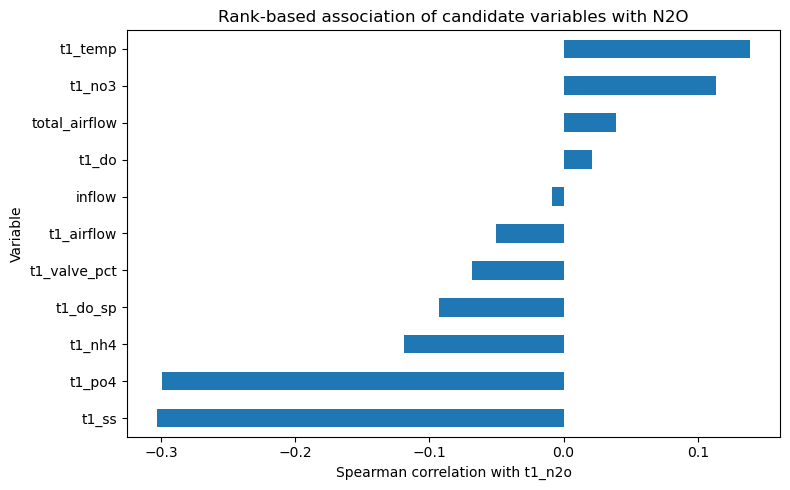

In [5]:
plt.figure(figsize=(8, 5))
spearman_corr.sort_values().plot(kind="barh")
plt.xlabel("Spearman correlation with t1_n2o")
plt.ylabel("Variable")
plt.title("Rank-based association of candidate variables with N2O")
plt.tight_layout()
plt.show()

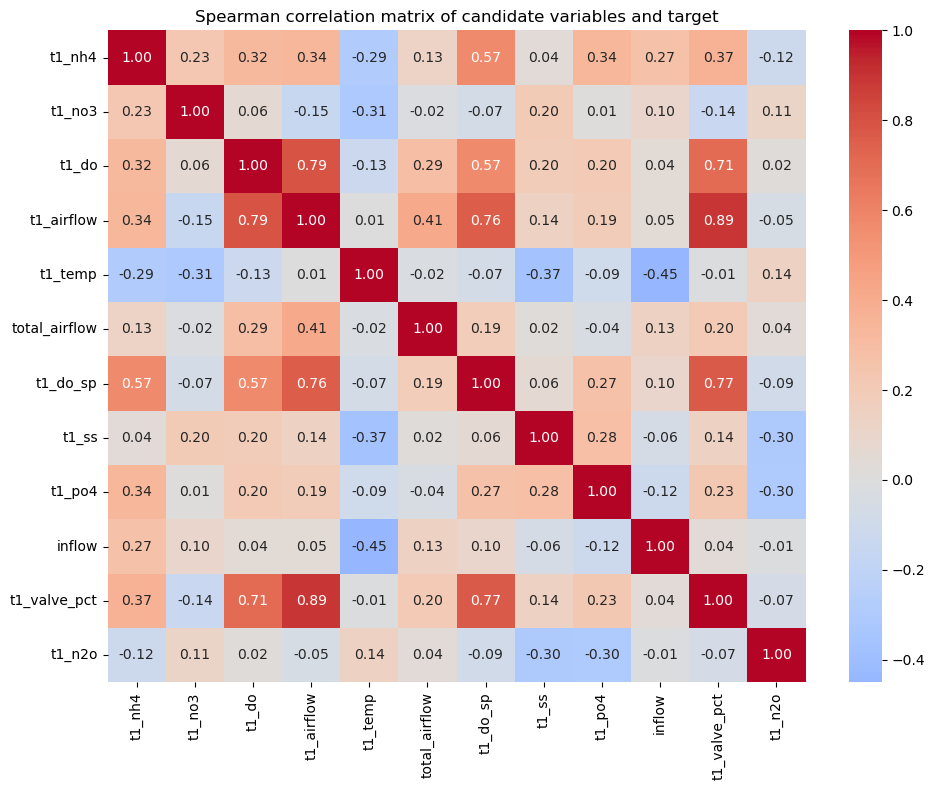

In [6]:
corr_vars = key_vars + [target]
corr_matrix = df[corr_vars].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation matrix of candidate variables and target")
plt.tight_layout()
plt.show()

In [7]:
# Variance Inflation Factor (VIF) for selected predictors

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use complete cases for VIF calculation
vif_df = feature_df[key_vars].dropna().copy()

vif_results = pd.DataFrame({
    "variable": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_results)

,variable,VIF
3,t1_airflow,20.967962
10,t1_valve_pct,15.757825
5,total_airflow,11.679067
4,t1_temp,11.317663
6,t1_do_sp,9.073725
7,t1_ss,8.898342
2,t1_do,4.951817
9,inflow,3.016222
0,t1_nh4,3.012314
8,t1_po4,2.979449


In [8]:
# Inspect pairwise correlations among the highest-VIF variables

high_vif_vars = ["t1_airflow", "t1_valve_pct", "total_airflow", "t1_temp", "t1_ss", "t1_do_sp"]
high_vif_vars = [col for col in high_vif_vars if col in feature_df.columns]

high_vif_corr = feature_df[high_vif_vars].corr(method="spearman")
display(high_vif_corr)

,t1_airflow,t1_valve_pct,total_airflow,t1_temp,t1_ss,t1_do_sp
t1_airflow,1.000000,0.891085,0.412332,0.007096,0.136450,0.756963
t1_valve_pct,0.891085,1.000000,0.204446,-0.010564,0.141524,0.765207
total_airflow,0.412332,0.204446,1.000000,-0.022559,0.021725,0.187116
t1_temp,0.007096,-0.010564,-0.022559,1.000000,-0.369712,-0.072362
t1_ss,0.136450,0.141524,0.021725,-0.369712,1.000000,0.062460
t1_do_sp,0.756963,0.765207,0.187116,-0.072362,0.062460,1.000000


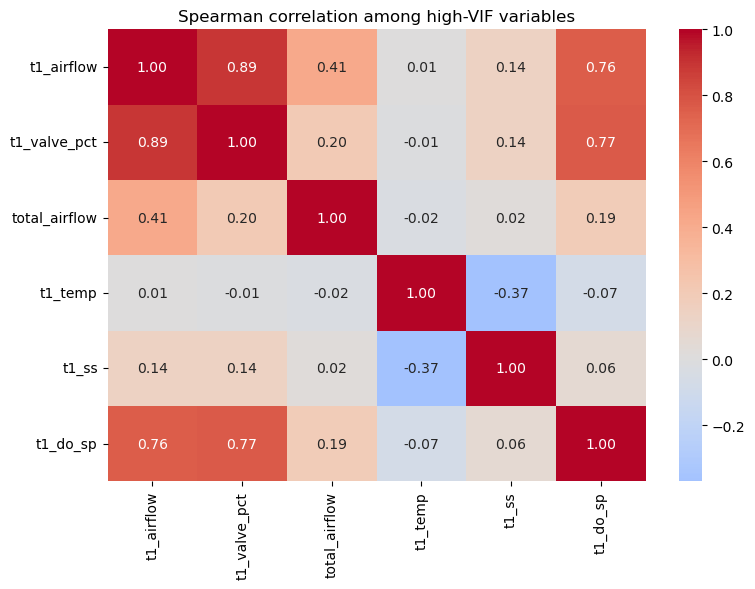

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(high_vif_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation among high-VIF variables")
plt.tight_layout()
plt.show()

In [10]:
vif_df2 = feature_df.drop(["t1_valve_pct", "t1_n2o"], axis=1)
vif_df2 = vif_df2.dropna()

vif_results2 = pd.DataFrame({
    "variable": vif_df2.columns,
    "VIF": [variance_inflation_factor(vif_df2.values, i) for i in range(vif_df2.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_results2)

,variable,VIF
3,t1_airflow,10.864323
4,t1_temp,10.796788
5,total_airflow,10.165335
7,t1_ss,8.792582
6,t1_do_sp,8.001522
2,t1_do,4.869778
0,t1_nh4,3.011552
9,inflow,2.994543
8,t1_po4,2.978812
1,t1_no3,2.433807


In [11]:
vif_df3 = feature_df.drop(["t1_valve_pct", "total_airflow", "t1_n2o"], axis=1)
vif_df3 = vif_df3.dropna()

vif_results3 = pd.DataFrame({
    "variable": vif_df3.columns,
    "VIF": [variance_inflation_factor(vif_df3.values, i) for i in range(vif_df3.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif_results3)

,variable,VIF
3,t1_airflow,8.856156
6,t1_ss,8.662793
4,t1_temp,7.969357
5,t1_do_sp,7.470338
2,t1_do,4.845887
0,t1_nh4,2.966267
7,t1_po4,2.948991
8,inflow,2.691239
1,t1_no3,2.415091


In [22]:
# Define feature sets to compare
feature_sets = {
    "Full set": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "total_airflow", "t1_do_sp", "t1_ss", "t1_po4",
        "inflow", "t1_valve_pct"
    ],
    "Without total_airflow": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow", "t1_valve_pct"
    ],
    "Without t1_valve_pct": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "total_airflow", "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "Without total_airflow and t1_valve_pct": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "Final retained set": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ]
}

# Keep only columns that actually exist in the dataframe
feature_sets = {
    name: [col for col in cols if col in feature_df.columns]
    for name, cols in feature_sets.items()
}

results = []

for name, vars_used in feature_sets.items():
    model_df = feature_df[[target] + vars_used].dropna().copy()

    X = model_df[vars_used]
    y = model_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)

    results.append({
        "feature_set": name,
        "n_features": len(vars_used),
        "features_used": ", ".join(vars_used),
        "n_rows": len(model_df),
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("RMSE")

display(results_df)

,feature_set,n_features,features_used,n_rows,R2,MAE,RMSE
2,Without t1_valve_pct,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",79924,0.047790,0.099959,0.145173
0,Full set,11,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",79924,0.047290,0.100011,0.145212
3,Without total_airflow and t1_valve_pct,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046768,0.100147,0.145251
4,Final retained set,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046768,0.100147,0.145251
1,Without total_airflow,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046388,0.100200,0.145280


These alternative feature-set comparisons were carried out to assess whether the exclusion of certain variables after the earlier correlation and VIF analysis was justified from a predictive point of view, rather than relying on redundancy diagnostics alone. Correlation and multicollinearity checks are useful for identifying overlap between predictors, but they do not show whether a variable still contributes useful signal once the other variables are considered jointly in a model. For this reason, it was important to compare model performance across fuller and reduced specifications in order to determine whether variables such as `t1_valve_pct` and `total_airflow` were genuinely informative, or whether they were largely duplicating information already captured elsewhere in the feature set.

The results show that predictive performance changed only very slightly across the different specifications. Excluding `t1_valve_pct` produced the best-performing Ridge model, with the highest R2 and the lowest MAE and RMSE, indicating that this variable did not provide useful additional signal beyond the other retained predictors and may instead have introduced a small amount of redundancy or noise. By contrast, excluding `total_airflow` led to a very slight worsening of performance, suggesting that this variable may contain some additional information not fully captured by the remaining predictors. However, the magnitude of this difference was extremely small.

Taken together, these results suggest that neither `t1_valve_pct` nor `total_airflow` was essential to model performance in this simple linear setting. The fuller feature sets did not deliver any meaningful predictive improvement over the reduced versions, despite containing more variables and greater multicollinearity. This supports the decision to favour the more parsimonious retained feature set, since it preserves almost all of the predictive signal present in the fuller specification while reducing redundancy and simplifying subsequent modelling. In other words, this analysis provides direct evidence that the variables removed after the earlier feature assessment were not discarded arbitrarily, but were excluded because they added little practical value once the core process-relevant predictors were already included.